# Ottimizzazione UMAP e HDBSCAN (Dataset 1.75M)
Questo notebook esegue il clustering definitivo sul dataset di produzione. Includiamo anche i grafici di topologia.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.clustering_hdbscan import run_umap_hdbscan

EMBEDDINGS_PATH = PROJECT_ROOT / "data/embeddings/email_embeddings.npy"
INDEX_PATH = PROJECT_ROOT / "data/metadata/email_embedding_index.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data/processed"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

## 1. Caricamento Dati
Carichiamo la matrice colossale da 2.6GB generata dalla pipeline BGE-Small.

In [2]:
print("Caricamento embeddings in corso...")
embeddings = np.load(EMBEDDINGS_PATH)
index_df = pd.read_parquet(INDEX_PATH)
print(f"Caricati {embeddings.shape[0]} vettori di dimensione {embeddings.shape[1]}")

Caricamento embeddings in corso...
Caricati 1757624 vettori di dimensione 384


## 2. Esecuzione UMAP e HDBSCAN
Fase di Sub-sampling e Inferenza su 1.75 Milioni di vettori. (Richiede ~30 minuti)

In [3]:
labels, probabilities, clusterer, reduced_embeddings = run_umap_hdbscan(
    embeddings=embeddings,
    n_neighbors=30,
    n_components=5,
    min_cluster_size=15,
    min_samples=3,
    cluster_selection_method="leaf",
    sample_size=100000
)

2026-06-18 10:09:36,451 - INFO - Dataset enorme (1757624 vettori). Eseguo sub-sampling a 100000 per addestramento UMAP e HDBSCAN.
2026-06-18 10:09:36,493 - INFO - Avvio addestramento UMAP su 100000 vettori da 384 dimensioni...
2026-06-18 10:09:36,493 - INFO - Parametri UMAP: n_neighbors=30, n_components=5, min_dist=0.01
/home/filippo/Scrivania/pizza-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-06-18 10:10:56,552 - INFO - UMAP addestrato. Nuova dimensionalità: (100000, 5)
2026-06-18 10:10:56,553 - INFO - Avvio addestramento HDBSCAN sui vettori ridotti...
2026-06-18 10:10:56,553 - INFO - Parametri HDBSCAN: min_cluster_size=15, min_samples=3, method='leaf'
2026-06-18 10:10:59,960 - INFO - Addestramento HDBSCAN completato sul campione. Cluster trovati: 923, Rumore: 65940
2026-06-18 10:10:59,960 - INFO - Proiezione dei restanti 1757624 vettori nei cluster...
2026-

## 3. Visualizzazione: Costellazione UMAP 2D
Disegniamo i primi due assi del nuovo spazio latente usando un campione di 50.000 punti per evitare crash grafici.

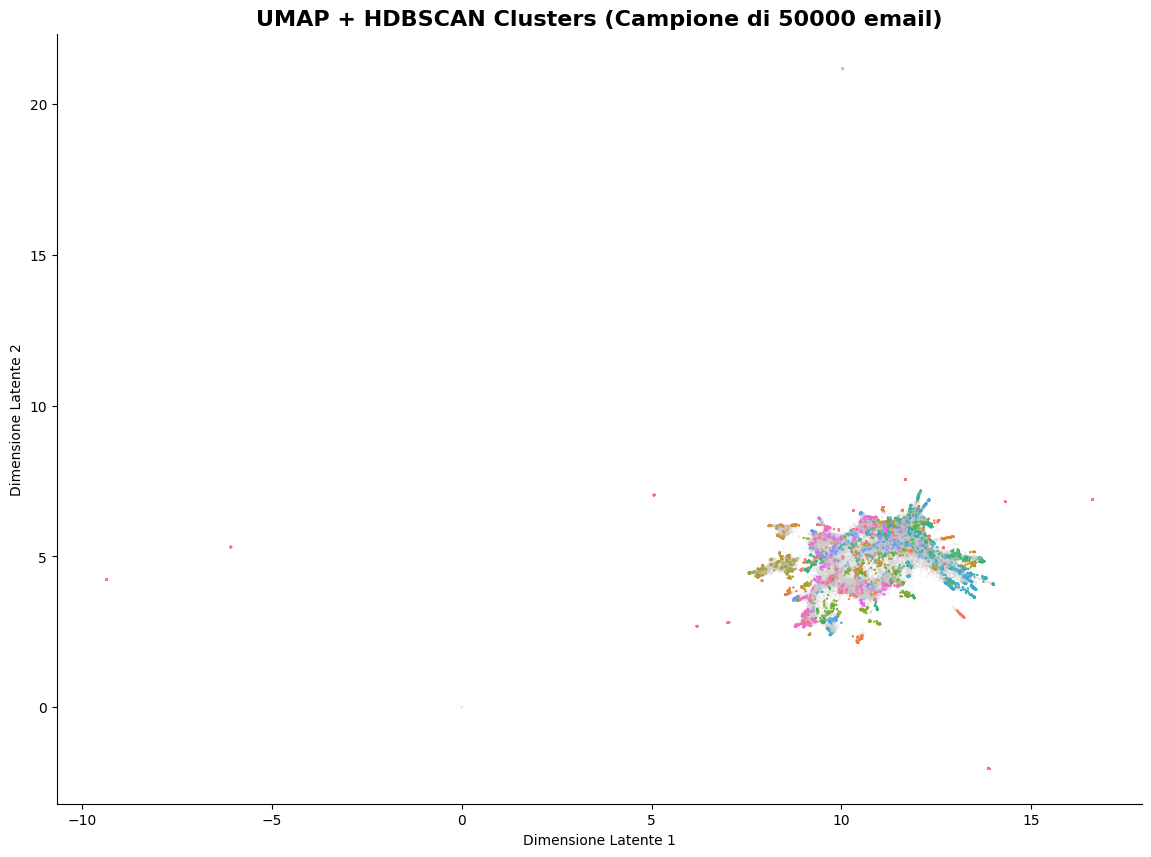

In [4]:
sample_size = 50000
np.random.seed(42)

if reduced_embeddings.shape[0] > sample_size:
    indices = np.random.choice(reduced_embeddings.shape[0], sample_size, replace=False)
    plot_data = reduced_embeddings[indices]
    plot_labels = labels[indices]
else:
    plot_data = reduced_embeddings
    plot_labels = labels

unique_labels = np.unique(plot_labels)
num_colors = len(unique_labels) - (1 if -1 in unique_labels else 0)
palette = sns.color_palette("husl", num_colors)

color_map = {-1: (0.8, 0.8, 0.8, 0.2)}
for i, lbl in enumerate(l for l in unique_labels if l != -1):
    r, g, b = palette[i]
    color_map[lbl] = (r, g, b, 1.0)

colors = [color_map[l] for l in plot_labels]

plt.figure(figsize=(14, 10))
plt.scatter(plot_data[:, 0], plot_data[:, 1], c=colors, s=3, linewidths=0)
plt.title(f"UMAP + HDBSCAN Clusters (Campione di {sample_size} email)", fontsize=16, fontweight='bold')
plt.xlabel("Dimensione Latente 1")
plt.ylabel("Dimensione Latente 2")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

## 4. Visualizzazione: Hyperparameter Sweep (Alberi di Densità HDBSCAN)
Generiamo una griglia 3x3 per visualizzare l'impatto di vari parametri. Aggiungiamo un leggero *jitter* matematico per evitare che eventuali punti perfettamente sovrapposti creino distanze pari a zero (bug dei Lambda Infiniti in HDBSCAN).

Avvio Hyperparameter Sweep. Generazione di 9 alberi di densità in corso...


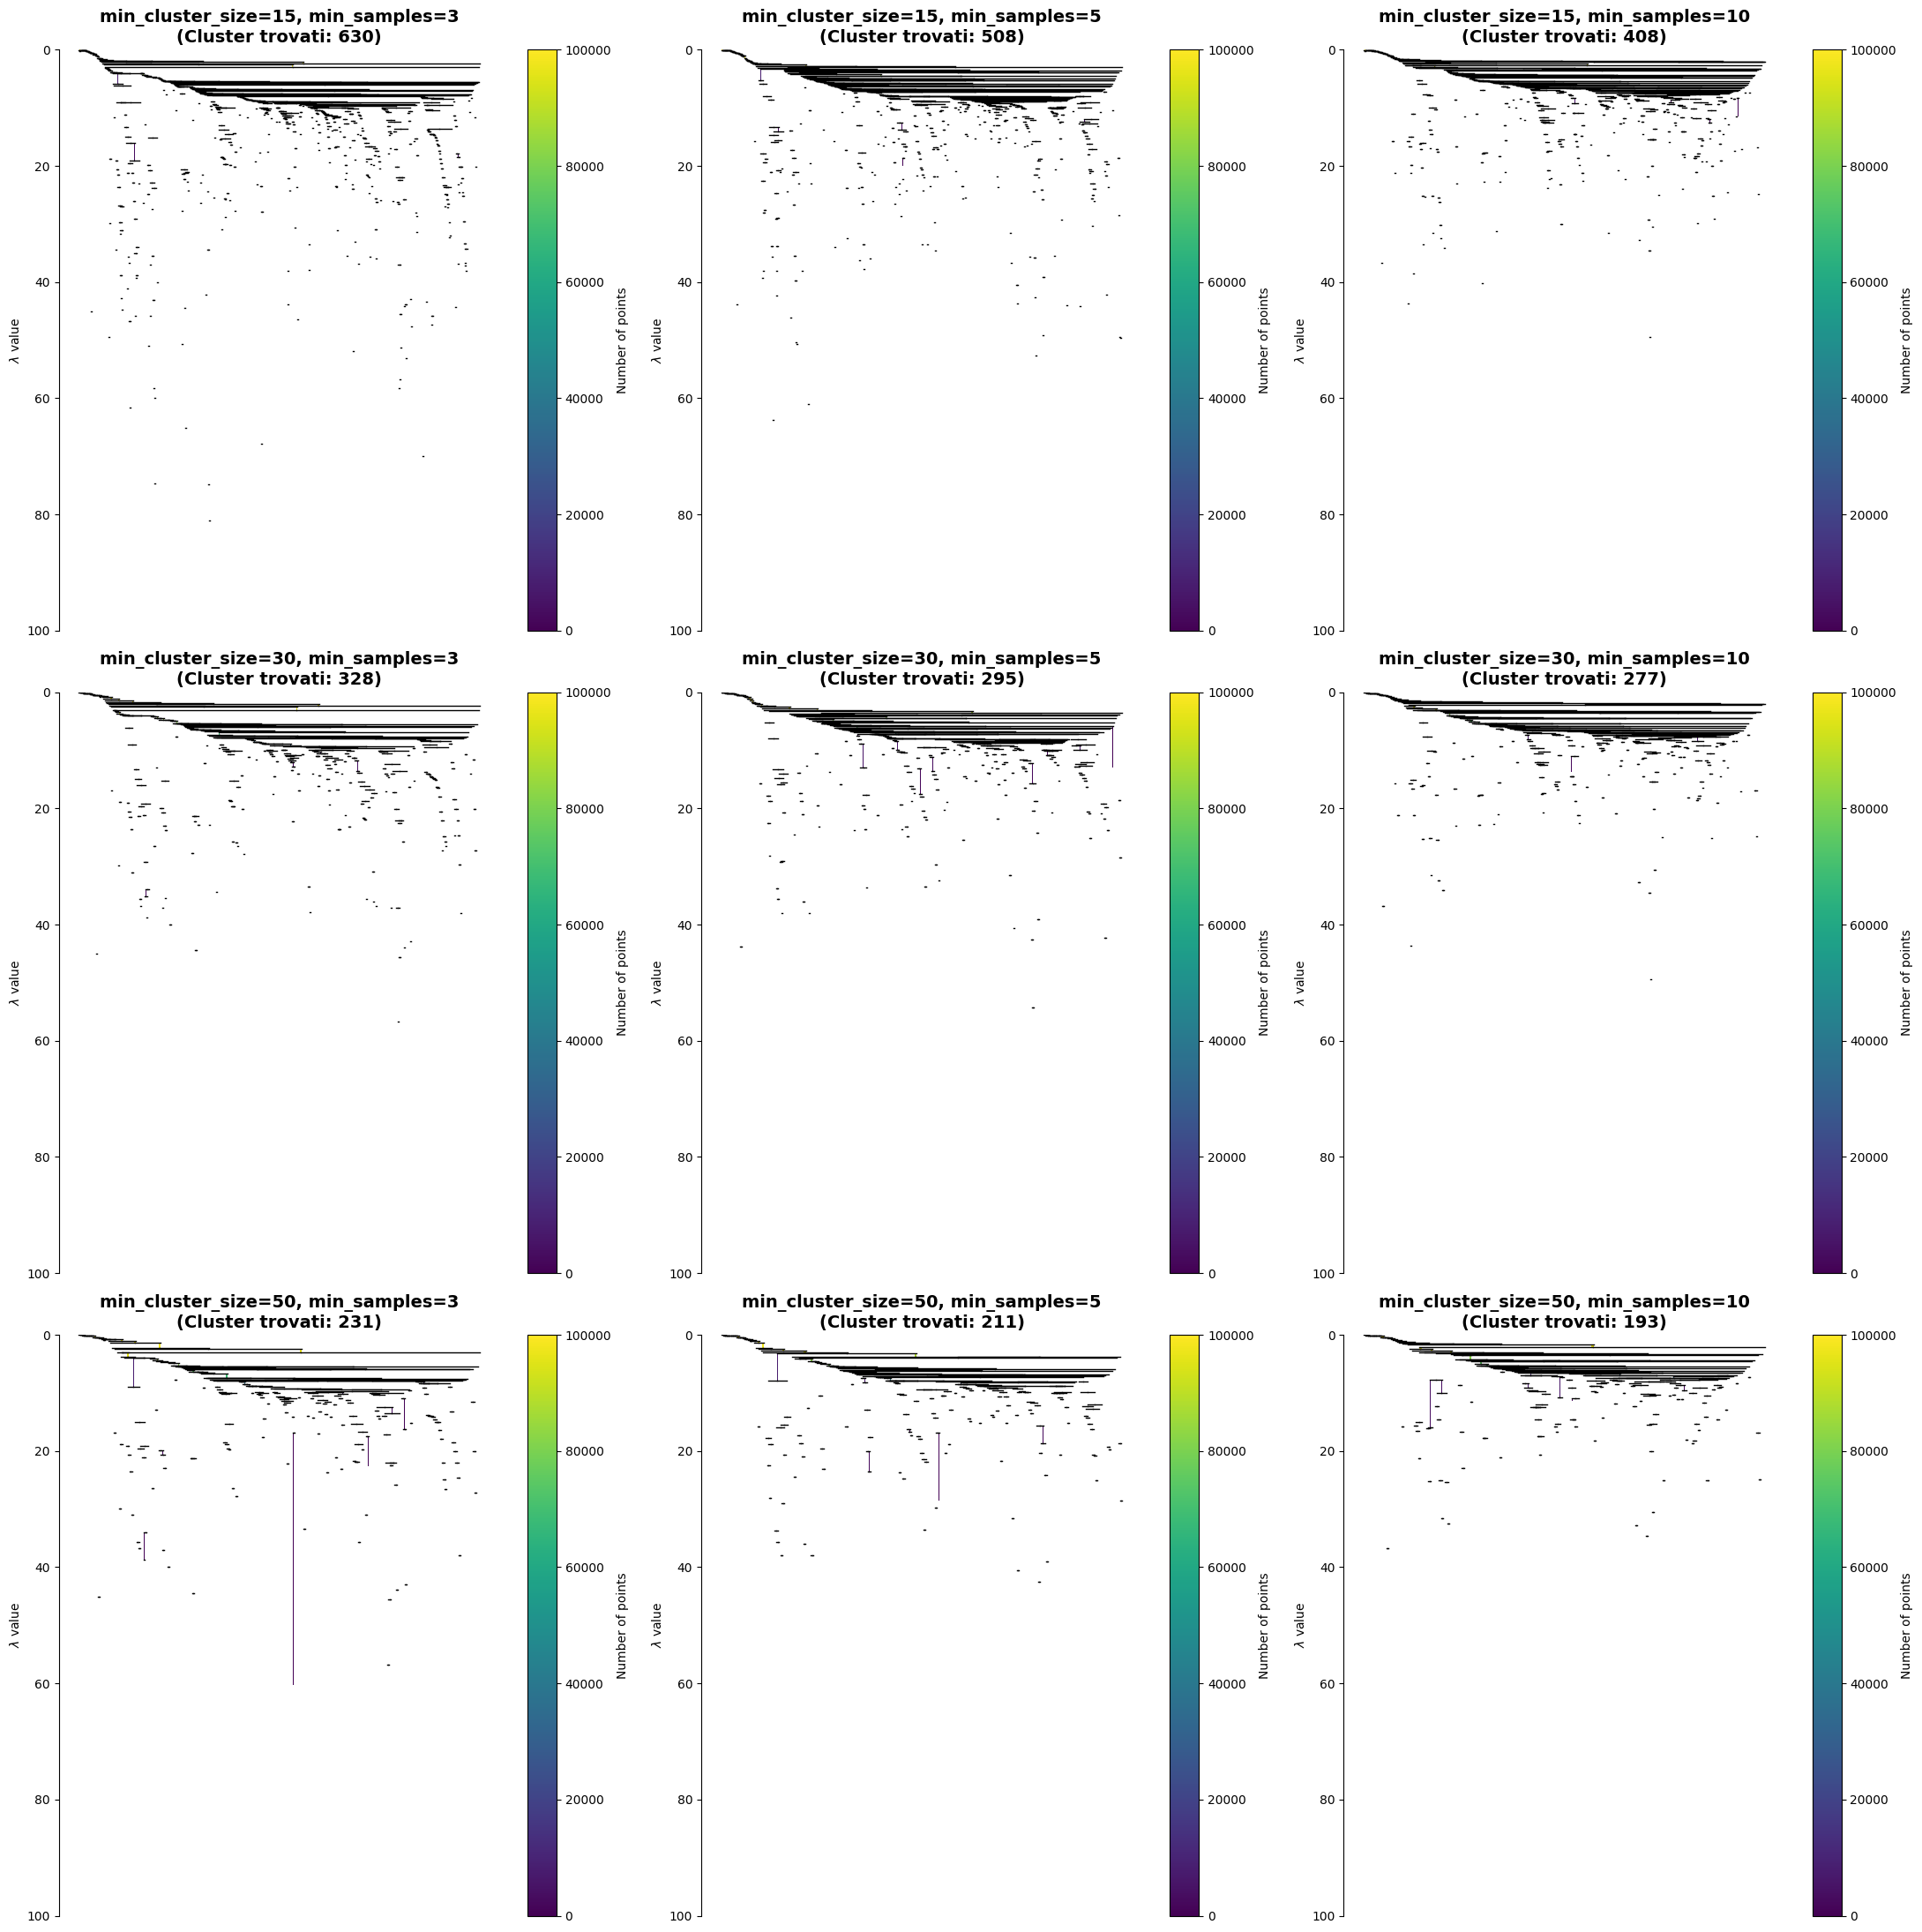

In [11]:
sample_size = 100000
np.random.seed(42)

if reduced_embeddings.shape[0] > sample_size:
    indices = np.random.choice(reduced_embeddings.shape[0], sample_size, replace=False)
    test_data = reduced_embeddings[indices]
else:
    test_data = reduced_embeddings

# Jitter potenziato a 0.01 per abbattere definitivamente il picco dei Lambda
test_data = test_data + np.random.normal(0, 0.01, test_data.shape)

min_cluster_sizes = [15, 30, 50]
min_samples_list = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(22, 22))
print("Avvio Hyperparameter Sweep. Generazione di 9 alberi di densità in corso...")

for i, mcs in enumerate(min_cluster_sizes):
    for j, ms in enumerate(min_samples_list):
        temp_clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric='euclidean',
            cluster_selection_method='leaf',
            core_dist_n_jobs=-1
        ).fit(test_data)
        
        ax = axes[i, j]
        n_clusters = len(set(temp_clusterer.labels_)) - (1 if -1 in temp_clusterer.labels_ else 0)
        hex_palette = sns.color_palette("husl", n_clusters).as_hex()
        
        try:
            # Ora che abbiamo salvato l'asse Y, possiamo riaccendere i colori!
            temp_clusterer.condensed_tree_.plot(
                select_clusters=False,
                selection_palette=hex_palette,
                axis=ax
            )
        except Exception as e:
            ax.text(0.5, 0.5, "Nessun Cluster Trovato o Errore", ha='center', va='center')
            
        ax.set_title(f"min_cluster_size={mcs}, min_samples={ms}\n(Cluster trovati: {n_clusters})", fontsize=14, fontweight='bold')
        ax.set_ylim(100,0)

plt.tight_layout()
plt.show()


## 5. Salvataggio Risultati
Prepariamo il dataframe finale per LLM.

In [6]:
index_df["cluster_id"] = labels
index_df["cluster_probability"] = probabilities

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Cluster totali: {n_clusters}")
print(f"Punti scartati come rumore: {n_noise} ({(n_noise/len(labels))*100:.2f}%)")

output_path = OUTPUT_DIR / "jmail_emails_clustered.parquet"
index_df.to_parquet(output_path, index=False)
print(f"Dati salvati in: {output_path}")

Cluster totali: 920
Punti scartati come rumore: 1284817 (73.10%)
Dati salvati in: /home/filippo/Scrivania/pizza-cluster/data/processed/jmail_emails_clustered.parquet
